## Comparison of binomial tree and 1D neural network

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from neural_network.trainer import GeneralTrainer
from neural_network.payoff import Put
from neural_network.config import MarketParams, ModelConfig

from black_scholes.tree import BinomialTree

from utility.plot import plot_price_heatmaps, plot_free_boundary

/Users/jameswu/Documents/Imperial/Year 4/M4R/M4R_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
S0 = 1.0
r = 0.1
sigma = 0.3
K = 1.0
T = 1.0
S_min = 0.0
S_max = 3 * K

market_params = MarketParams(n_assets=1, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)
exercise_type = "american"

In [3]:
bt = BinomialTree(market_params, exercise_type=exercise_type, n_steps=100)

In [4]:
input_size = 2
hidden_sizes = [64, 128, 128, 64]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.0001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [5]:
put_payoff = Put()
trainer = GeneralTrainer(model_config, market_params, put_payoff, exercise_type=exercise_type, seed=7)
optimal_weights = trainer.optimise_loss_weights(
    batch_size=1000, n_trials=30, epochs_per_trial=300
)
print("Optimal Loss Weights:", optimal_weights)

[I 2026-03-04 16:21:12,605] A new study created in memory with name: no-name-0304b3cd-dfee-49b8-ad5e-97384fc8ccf6
Best trial: 0. Best value: 0.0012659:   3%|▎         | 1/30 [00:06<02:54,  6.02s/it]

[I 2026-03-04 16:21:18,633] Trial 0 finished with value: 0.001265901359729469 and parameters: {'pde': 0.4532970584334324, 'exercise': 2.2062032827893847, 'boundary_Smax': 0.02485587540945373, 'boundary_Smin': 0.011445567950361413}. Best is trial 0 with value: 0.001265901359729469.


Best trial: 0. Best value: 0.0012659:   7%|▋         | 2/30 [00:11<02:41,  5.76s/it]

[I 2026-03-04 16:21:24,205] Trial 1 finished with value: 0.031789029892534015 and parameters: {'pde': 18.381042206335717, 'exercise': 1.7979099584794664, 'boundary_Smax': 0.015411671816727446, 'boundary_Smin': 0.1871449138401652}. Best is trial 0 with value: 0.001265901359729469.


Best trial: 0. Best value: 0.0012659:  10%|█         | 3/30 [00:17<02:35,  5.77s/it]

...

[I 2026-03-04 16:23:11,802] Trial 27 pruned. 


Best trial: 26. Best value: 1.66702e-05:  97%|█████████▋| 29/30 [02:01<00:03,  3.16s/it]

[I 2026-03-04 16:23:13,788] Trial 28 pruned. 


Best trial: 26. Best value: 1.66702e-05: 100%|██████████| 30/30 [02:03<00:00,  4.10s/it]

[I 2026-03-04 16:23:15,765] Trial 29 pruned. 
Optimal Loss Weights: {'pde': 0.010996713687421592, 'exercise': 0.01983776289920463, 'boundary_Smax': 0.0010757715096086549, 'boundary_Smin': 0.02492519343787631}


In [6]:
trainer.set_loss_weights(optimal_weights)
print("Training with optimal loss weights...")
print(trainer.loss_weights)
trainer.train(batch_size=1000, epochs=10000, tol=1e-9)


Training with optimal loss weights...
{'pde': 0.19348338625682435, 'exercise': 0.3490385992215528, 'boundary_Smax': 0.01892782884360992, 'boundary_Smin': 0.43855018567801296}
Iteration 0, Loss: 0.5282340049743652
Iteration 100, Loss: 0.12071394920349121
Iteration 200, Loss: 0.003741850610822439
Iteration 300, Loss: 0.00038178026443347335
Iteration 400, Loss: 0.00012119670282118022
Iteration 500, Loss: 8.018120570341125e-05
Iteration 600, Loss: 6.076874342397787e-05
Iteration 700, Loss: 4.425256702234037e-05
Iteration 800, Loss: 4.4591106416191906e-05
Iteration 900, Loss: 3.88357657357119e-05
Iteration 1000, Loss: 3.3274995075771585e-05
Iteration 1100, Loss: 3.0162995244609192e-05
Iteration 1200, Loss: 3.047770405828487e-05
Iteration 1300, Loss: 2.4913300876505673e-05
Iteration 1400, Loss: 2.465557372488547e-05
Iteration 1500, Loss: 2.1294916223268956e-05
Iteration 1600, Loss: 2.2373653337126598e-05
Iteration 1700, Loss: 2.194260923715774e-05
Iteration 1800, Loss: 2.1217090761638246e-05

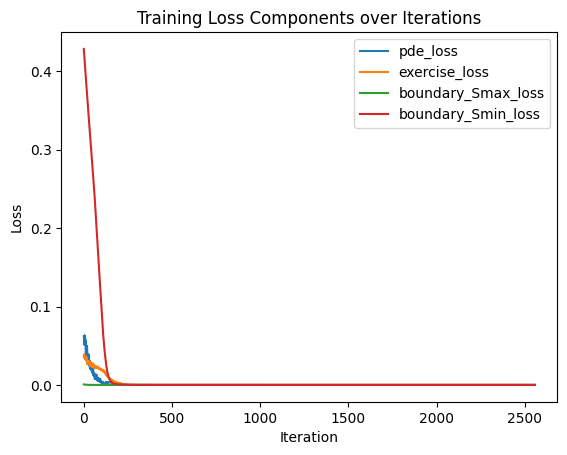

In [7]:
trainer.plot_losses_detailed()

In [8]:
# grid resolution
num_S = 80
num_T = 80

Ss = np.linspace(S_min, S_max, num_S)
Ts = np.linspace(0, T-1e-4, num_T)  # avoid exactly zero maturity

nn_prices = np.zeros((num_T, num_S))
bt_prices = np.zeros((num_T, num_S))

for i, t_val in enumerate(Ts):
    for j, s_val in enumerate(Ss):
        nn_prices[i, j] = trainer.predict(t_val, s_val).item()
        bt_prices[i, j] = bt.predict(t_val, s_val)

/var/folders/yc/lmxhkkxd611c8bx7dqjsmvr40000gn/T/ipykernel_38184/3584896141.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bt_prices[i, j] = bt.predict(t_val, s_val)


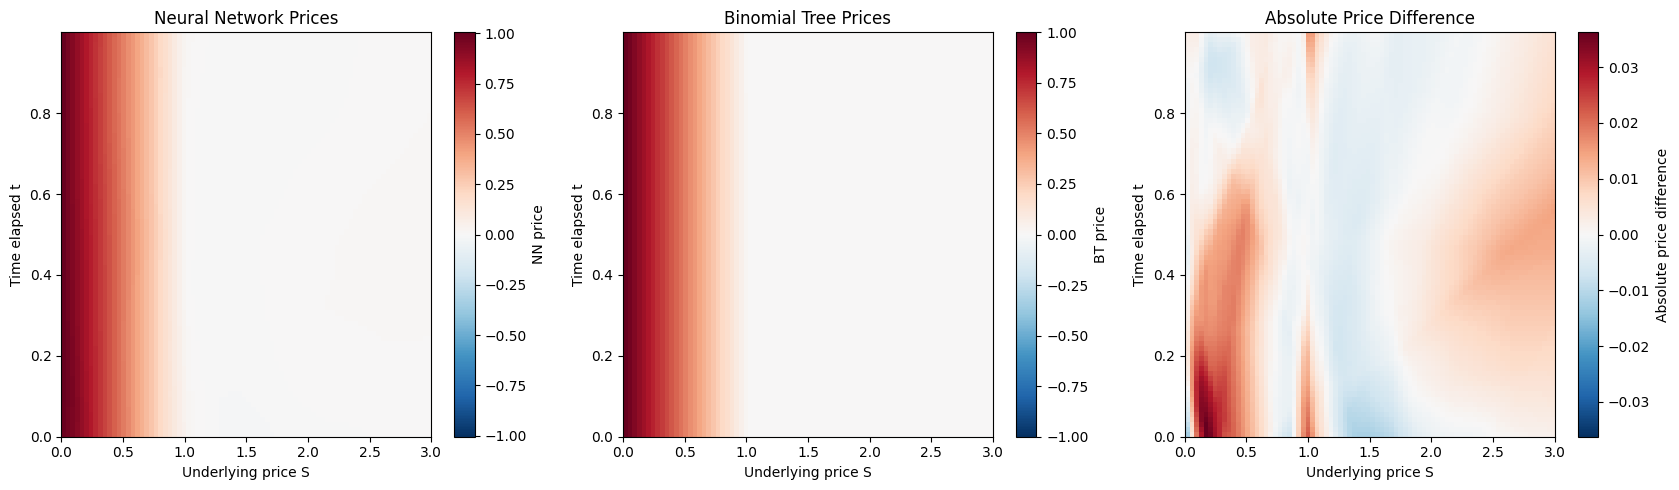

In [9]:
plot_price_heatmaps(
    prices1=nn_prices, prices2=bt_prices,
    xlabel='Underlying price S', ylabel='Time elapsed t',
    title1='Neural Network Prices', title2='Binomial Tree Prices', title_diff='Absolute Price Difference',
    label1='NN price', label2='BT price', label_diff='Absolute price difference',
    extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]]
)

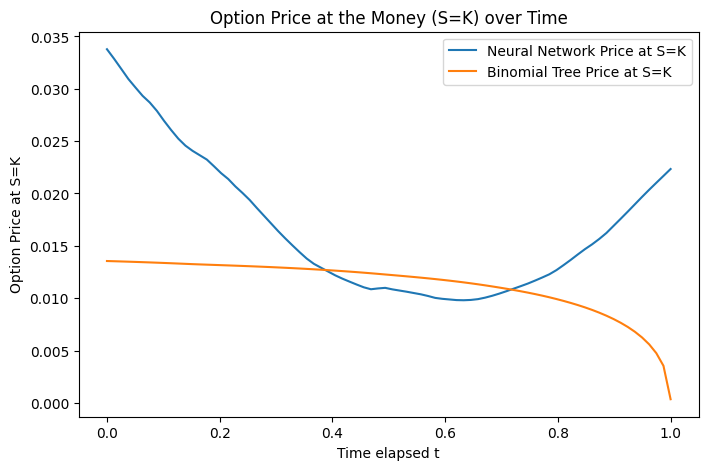

In [10]:
# Error at the money
S_try = K
nn_prices_atm = [trainer.predict(t, S_try).item() for t in Ts]
bt_prices_atm = [bt.predict(t, S_try) for t in Ts]

plt.figure(figsize=(8, 5))
plt.plot(Ts, nn_prices_atm, label='Neural Network Price at S=K')
plt.plot(Ts, bt_prices_atm, label='Binomial Tree Price at S=K')
plt.xlabel('Time elapsed t')
plt.ylabel('Option Price at S=K')
plt.title('Option Price at the Money (S=K) over Time')
plt.legend()
plt.show()

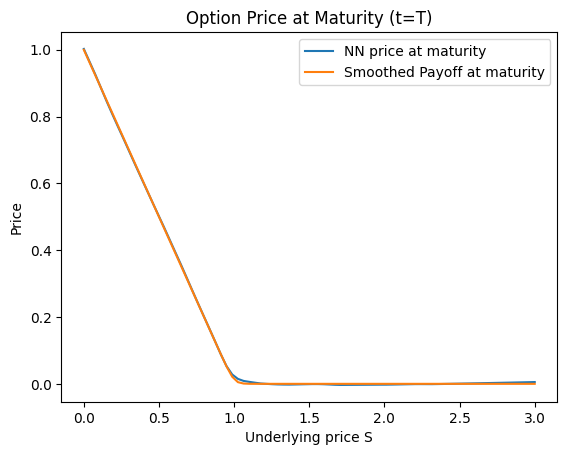

In [11]:
# Payoff price
t_ind = -1
plt.plot(Ss, nn_prices[t_ind, :], label='NN price at maturity')
# plt.plot(Ss, bt_prices[t_ind, :], label='Tree price at maturity')
plt.plot(Ss, put_payoff.smoothed(torch.tensor(Ss), K, beta=50), label='Smoothed Payoff at maturity')
plt.xlabel('Underlying price S')
plt.ylabel('Price')
plt.title('Option Price at Maturity (t=T)')
plt.legend()
plt.show()

### Fine tune the network

In [12]:
trainer.fine_tune(batch_size=1000, epochs=10000, tol=1e-2)

Fine-tuning iteration 0, Loss: 1.498778692621272e-05
Fine-tuning iteration 100, Loss: 1.3771539215667872e-06
Fine-tuning iteration 200, Loss: 8.761051617511839e-07
Early stopping at epoch 200


In [13]:
# grid resolution
num_S = 80
num_T = 80

Ss = np.linspace(S_min, S_max, num_S)
Ts = np.linspace(0, T-1e-4, num_T)  # avoid exactly zero maturity

nn_prices = np.zeros((num_T, num_S))
bt_prices = np.zeros((num_T, num_S))

for i, t_val in enumerate(Ts):
    for j, s_val in enumerate(Ss):
        nn_prices[i, j] = trainer.predict(t_val, s_val).item()
        bt_prices[i, j] = bt.predict(t_val, s_val)

/var/folders/yc/lmxhkkxd611c8bx7dqjsmvr40000gn/T/ipykernel_38184/3584896141.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bt_prices[i, j] = bt.predict(t_val, s_val)


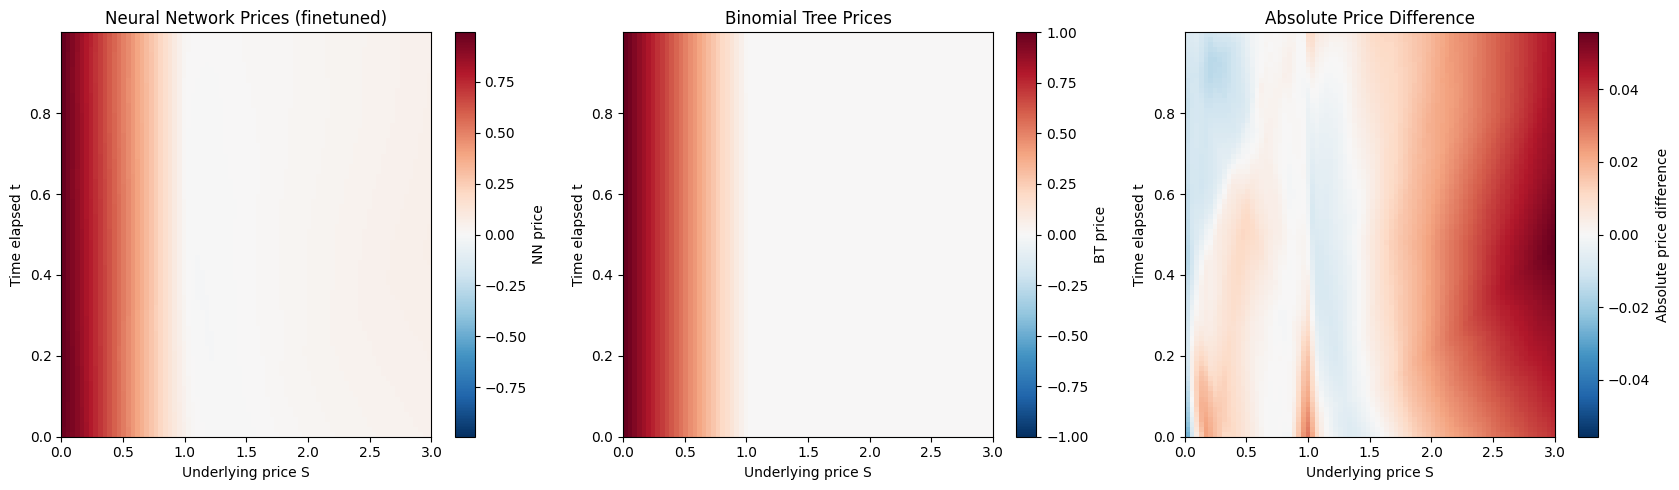

In [14]:
plot_price_heatmaps(
    prices1=nn_prices, prices2=bt_prices,
    xlabel='Underlying price S', ylabel='Time elapsed t',
    title1='Neural Network Prices (finetuned)', title2='Binomial Tree Prices', title_diff='Absolute Price Difference',
    label1='NN price', label2='BT price', label_diff='Absolute price difference',
    extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]]
)

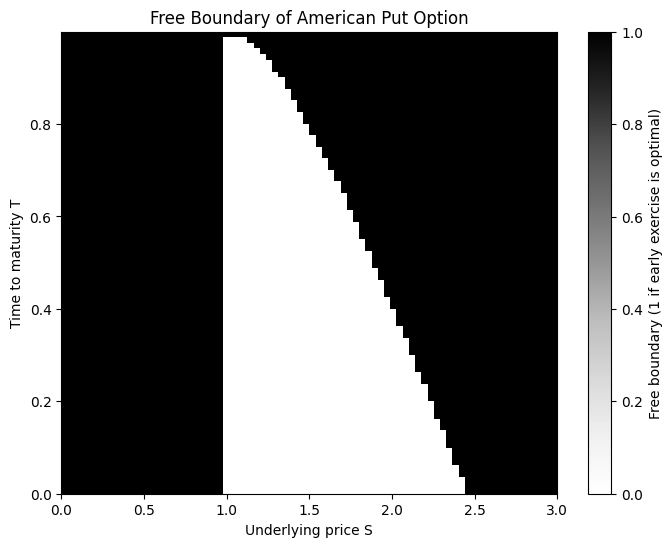

In [15]:
plot_free_boundary(bt_prices, K, Ss, Ts, xlabel='Underlying price S', ylabel='Time to maturity T', title='Free Boundary of American Put Option')